# COTSIM boundary demonstration

**Author:** Abdourahmane Diaw (diawa@ornl.gov, Oak Ridge National Laboratory)

## Workflow

1. Import the SOLSTICE model hub and COTSIM utilities.
2. Load the released state-model bundle.
3. Supply the operating point and SOLPS/EIRENE boundary diagnostics.
4. Call the neural network to obtain the 2D plasma state.
5. Reduce the state to flux-surface and outer-midplane profiles for COTSIM.


In [1]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import LogNorm, SymLogNorm
plt.rcParams.update({
    'text.usetex': False,  # Matplotlib mathtext: LaTeX-style labels without a system TeX install
    'font.size': 16, 'axes.titlesize': 20, 'axes.labelsize': 18,
    'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 16,
    'figure.titlesize': 21, 'lines.linewidth': 2.0,
})

ROOT = Path.cwd().resolve()
if (ROOT / 'examples' / 'cotsim').is_dir():
    sys.path.insert(0, str(ROOT / 'examples' / 'cotsim'))
else:
    sys.path.insert(0, str(ROOT.parent))
from boundary import mesh_rows, flux_coordinate, profiles, at_rho, targets, ion_density
from solstice import hub

BUNDLE = 'pepc-diiid-cotsim-677-state'
RHO_C = 0.95
params = {
    'ptot': 1.299e7, 'puff_D2': 1.623e21, 'core_fueling': 1.0e20,
    'dna': 0.3, 'chi': 0.3, 'gamma_b_in': 9.312e20,
    'gamma_b_out': 2.691e21, 'p_b_in': 68.47, 'p_b_out': 1.304e7,
}
model = hub.load(BUNDLE)
print('loaded:', model.manifest['name'])
print('model inputs:', model.inputs)

loaded: pepc-diiid-cotsim-677-state
model inputs: ['chi', 'core_fueling', 'dna', 'gamma_b_in', 'gamma_b_out', 'p_b_in', 'p_b_out', 'ptot', 'puff_D2']


The following cells load the model, define the operating point, call the network, and prepare the COTSIM profiles.

In [2]:
pred = model.predict_batch(params)
fields = {k: v[0] for k, v in pred['mean'].items()}
ni, ni_note = ion_density(fields, model.fields)
geom = mesh_rows(model.mesh)
fc = flux_coordinate(geom, RHO_C, 'psin', None, None)
prof = profiles(fields, geom, fc['x'], ni)
bc = at_rho(prof, RHO_C)
tg = targets(fields, model.mesh)

print('COTSIM boundary inputs:')
for name in ('gamma_b_in', 'gamma_b_out', 'p_b_in', 'p_b_out'):
    print(f'  {name:12s} = {params[name]:.6e}')
print('\nSOLSTICE state at rho_c=0.95:')
for name, unit in (('te', 'eV'), ('ti', 'eV'), ('ne', 'm^-3'), ('ni', 'm^-3')):
    print(f'  {name:3s} FSA={bc[name]["fsa"]:.6e} {unit}, OMP={bc[name]["omp"]:.6e} {unit}')
print(f'\nP_rad = {tg["P_rad_W"]:.6e} W')
for target in ('inner_target', 'outer_target'):
    print(f'{target}: q_peak = {tg[target]["q_peak_W_m2"]:.6e} W/m^2')

COTSIM boundary inputs:
  gamma_b_in   = 9.312000e+20
  gamma_b_out  = 2.691000e+21
  p_b_in       = 6.847000e+01
  p_b_out      = 1.304000e+07

SOLSTICE state at rho_c=0.95:
  te  FSA=3.356422e+03 eV, OMP=3.369978e+03 eV
  ti  FSA=3.042279e+03 eV, OMP=3.040865e+03 eV
  ne  FSA=3.191694e+19 m^-3, OMP=3.187484e+19 m^-3
  ni  FSA=3.191676e+19 m^-3, OMP=3.187540e+19 m^-3

P_rad = 7.301951e+05 W
inner_target: q_peak = 1.165006e+07 W/m^2
outer_target: q_peak = 5.781895e+07 W/m^2


## Predicted two-dimensional plasma state

These panels show the neural-network prediction on the SOLPS computational mesh. The color fields are the quantities later reduced to `rho_c` profiles.

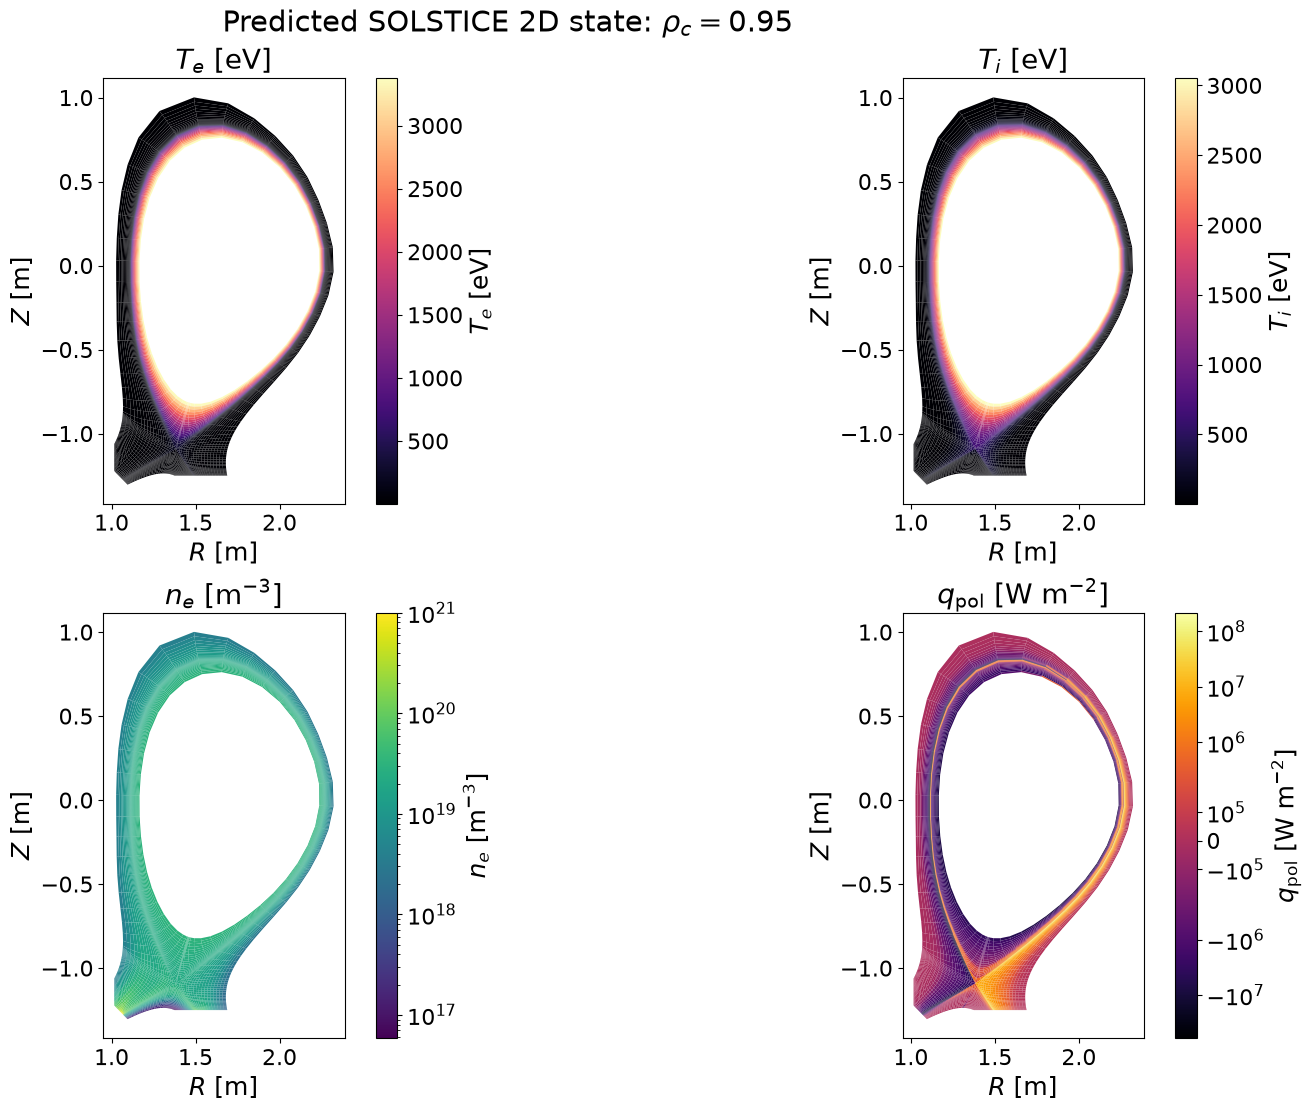

In [3]:
corner_r = np.asarray(model.mesh['cell_corners_r'])
corner_z = np.asarray(model.mesh['cell_corners_z'])
fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
panels = [('te', r'$T_e$ [eV]', 'magma', None), ('ti', r'$T_i$ [eV]', 'magma', None),
          ('ne', r'$n_e$ [$\mathrm{m}^{-3}$]', 'viridis', 'log'),
          ('q_pol', r'$q_{\mathrm{pol}}$ [W m$^{-2}$]', 'inferno', 'symlog')]
for ax, (name, label, cmap, scale) in zip(axes.flat, panels):
    values = np.asarray(fields[name])
    polygons = np.stack((corner_r, corner_z), axis=-1)
    if scale == 'log':
        positive = values[values > 0]
        norm = LogNorm(vmin=positive.min(), vmax=positive.max())
    elif scale == 'symlog':
        norm = SymLogNorm(linthresh=max(1.0, 1e-3 * np.nanmax(np.abs(values))), vmin=np.nanmin(values), vmax=np.nanmax(values))
    else:
        norm = None
    collection = PolyCollection(polygons, array=values, cmap=cmap, norm=norm, edgecolors='none', linewidths=0)
    ax.add_collection(collection); ax.autoscale_view()
    ax.set_xlabel(r'$R$ [m]'); ax.set_ylabel(r'$Z$ [m]'); ax.set_title(label)
    ax.set_aspect('equal', adjustable='box'); fig.colorbar(collection, ax=ax, label=label)
fig.suptitle(r'Predicted SOLSTICE 2D state: $\rho_c=0.95$')
plt.show()

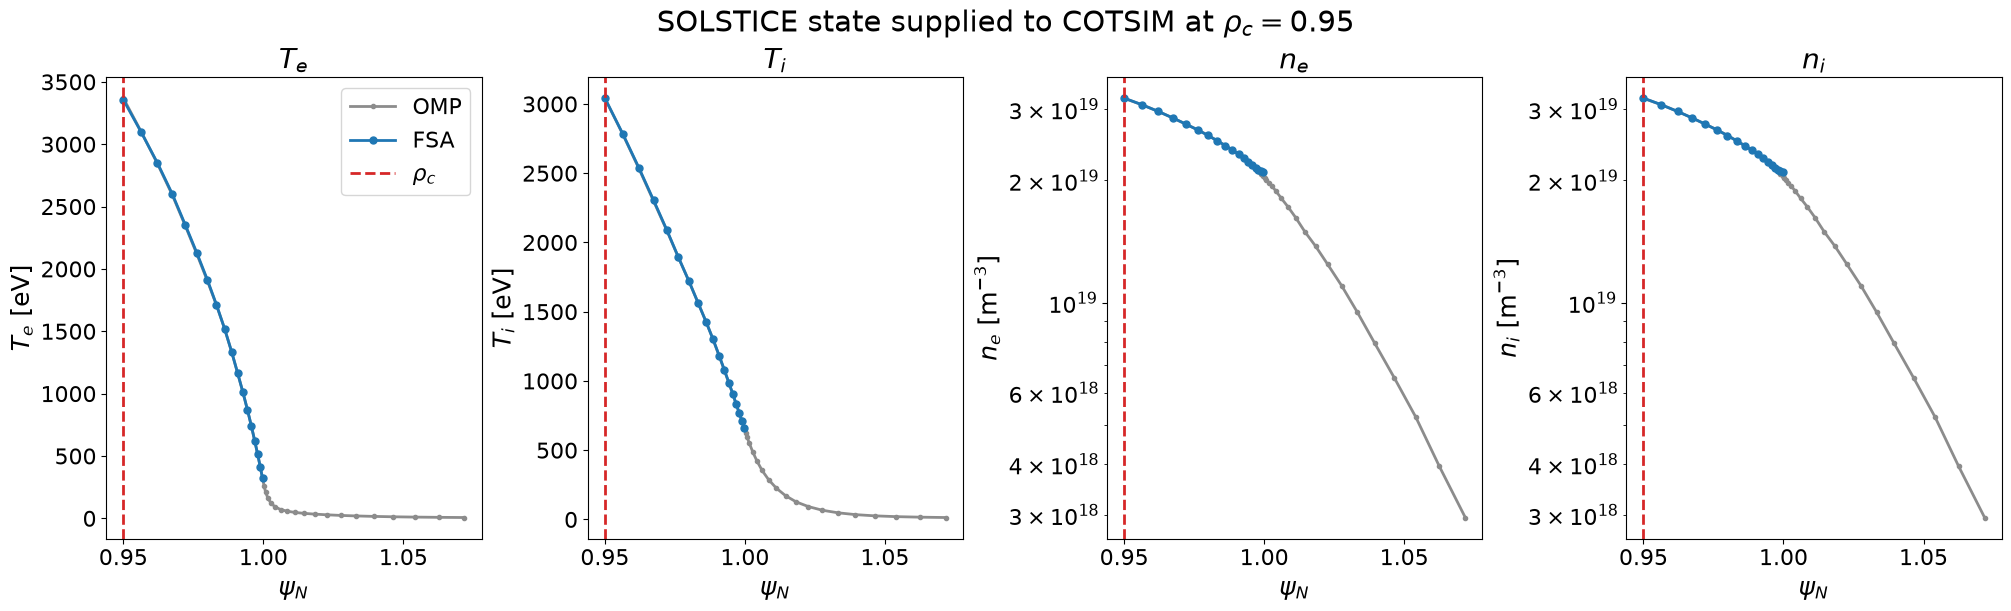

In [4]:
x = np.asarray(prof['x'])
closed = np.asarray(prof['closed'])
fig, axes = plt.subplots(1, 4, figsize=(20, 6), constrained_layout=True)
labels = [('te', r'$T_e$ [eV]'), ('ti', r'$T_i$ [eV]'), ('ne', r'$n_e$ [$\mathrm{m}^{-3}$]'), ('ni', r'$n_i$ [$\mathrm{m}^{-3}$]')]
for ax, (name, ylabel) in zip(axes, labels):
    ax.plot(x, prof[f'{name}_omp'], '.-', color='0.55', label='OMP')
    ax.plot(x[closed], np.asarray(prof[f'{name}_fsa'])[closed], 'o-', ms=5, label='FSA')
    ax.axvline(RHO_C, color='tab:red', ls='--', label=r'$\rho_c$')
    ax.set_title(ylabel.split(' [')[0]); ax.set_xlabel(r'$\psi_N$'); ax.set_ylabel(ylabel)
    if name in ('ne', 'ni'): ax.set_yscale('log')
axes[0].legend(); fig.suptitle(r'SOLSTICE state supplied to COTSIM at $\rho_c=0.95$')
plt.show()

In [5]:
result = {
    'bundle': model.manifest['name'], 'rho_c': RHO_C,
    'cotsim_boundary_inputs': params, 'boundary_conditions': bc,
    'targets': tg, 'profiles': prof, 'ni_definition': ni_note,
}
out = Path('cotsim_boundary_demo.json')
def json_safe(value):
    if isinstance(value, dict): return {k: json_safe(v) for k, v in value.items()}
    if isinstance(value, list): return [json_safe(v) for v in value]
    if isinstance(value, (float, np.floating)) and not np.isfinite(value): return None
    if isinstance(value, (np.integer,)): return int(value)
    if isinstance(value, np.ndarray): return json_safe(value.tolist())
    return value
out.write_text(json.dumps(json_safe(result), indent=2, allow_nan=False))
print('wrote', out.resolve())

wrote /tmp/diawa_cotsim677/solstice/examples/cotsim/cotsim_boundary_demo.json
